In [ ]:
!pip install kaggle --quiet


In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'PRAHA2006'  # your Kaggle username
os.environ['KAGGLE_KEY'] = 'KGAT_32bedc344439a60c757c6c5f50744dea'  # your API token


In [ ]:
# Download PlantVillage dataset from Kaggle
!kaggle datasets download -d emmarex/plantdisease

# Unzip to Colab folder
!unzip -q plantdisease.zip -d /content/PlantVillage_split


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 99% 648M/658M [00:01<00:00, 294MB/s]
100% 658M/658M [00:01<00:00, 389MB/s]


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [5]:
!ls /kaggle/input/plantdisease



plantvillage  PlantVillage


In [6]:
!ls /kaggle/input/plantdisease/PlantVillage



Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [11]:
!cp -r /kaggle/input/plantdisease/PlantVillage /content/PlantVillage



In [13]:
!ls /content/PlantVillage


Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [14]:
import os

BASE_SPLIT = "/content/PlantVillage_split"

train_dir = os.path.join(BASE_SPLIT, "train")
val_dir   = os.path.join(BASE_SPLIT, "val")
test_dir  = os.path.join(BASE_SPLIT, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("train / val / test folders created")


train / val / test folders created


In [15]:
import shutil
import random

SOURCE_DIR = "/content/PlantVillage"

train_ratio = 0.7
val_ratio   = 0.15

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end   = train_end + int(total * val_ratio)

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, class_name, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_dir, class_name, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(test_dir, class_name, img)
        )

print("✅ Dataset successfully split!")



✅ Dataset successfully split!


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

train_dir = "/content/PlantVillage_split/train"
val_dir   = "/content/PlantVillage_split/val"
test_dir  = "/content/PlantVillage_split/test"



In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
print("Classes:", NUM_CLASSES)


Found 14441 images belonging to 15 classes.
Found 3088 images belonging to 15 classes.
Found 3109 images belonging to 15 classes.
Classes: 15


In [18]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 220s 446ms/step - accuracy: 0.3476 - loss: 2.1272 - val_accuracy: 0.7403 - val_loss: 0.9338
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 177s 391ms/step - accuracy: 0.6659 - loss: 1.0562 - val_accuracy: 0.8067 - val_loss: 0.6802
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 173s 384ms/step - accuracy: 0.7405 - loss: 0.8172 - val_accuracy: 0.8212 - val_loss: 0.5850
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 172s 380ms/step - accuracy: 0.7774 - loss: 0.6862 - val_accuracy: 0.8384 - val_loss: 0.5268
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 172s 380ms/step - accuracy: 0.7943 - loss: 0.6477 - val_accuracy: 0.8488 - val_loss: 0.4791
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 174s 384ms/step - accuracy: 0.8035 - loss: 0.5990 - val_accuracy: 0.8546 - val_loss: 0.4625
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 171s 379ms/step - accuracy: 0.8191 - loss: 0.5409 - val_accuracy: 0.8614 - val_loss: 0.4359
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 172s 381ms/step - accuracy: 0.8306 -

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 212s 425ms/step - accuracy: 0.6550 - loss: 1.1263 - val_accuracy: 0.8595 - val_loss: 0.4213
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 176s 389ms/step - accuracy: 0.8359 - loss: 0.4950 - val_accuracy: 0.8731 - val_loss: 0.3859
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 178s 394ms/step - accuracy: 0.8621 - loss: 0.4213 - val_accuracy: 0.8880 - val_loss: 0.3380
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 174s 386ms/step - accuracy: 0.8739 - loss: 0.3678 - val_accuracy: 0.9022 - val_loss: 0.2981
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 176s 389ms/step - accuracy: 0.8951 - loss: 0.3159 - val_accuracy: 0.9129 - val_loss: 0.2604
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 179s 397ms/step - accuracy: 0.9006 - loss: 0.2870 - val_accuracy: 0.9142 - val_loss: 0.2477
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 177s 392ms/step - accuracy: 0.9103 - loss: 0.2707 - val_accuracy: 0.9229 - val_loss: 0.2241
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 175s 387ms/step - accuracy: 0.9121 -

In [21]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)


98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9502 - loss: 0.1488
Test Accuracy: 0.9379221796989441


In [23]:
model.save("PlantVillage_MobileNetV2.keras")



In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# True labels
y_true = test_gen.classes

# Predict probabilities
y_pred_probs = model.predict(test_gen)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(test_gen.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.99      0.98       151
                     Pepper__bell___healthy       0.99      1.00      0.99       223
                      Potato___Early_blight       0.99      0.98      0.99       150
                       Potato___Late_blight       0.96      0.94      0.95       150
                           Potato___healthy       0.96      0.96      0.96        24
                      Tomato_Bacterial_spot       0.95      0.96      0.95       320
                        Tomato_Early_blight       0.93      0.65      0.77       150
                         Tomato_Late_blight       0.95      0.96      0.95       287
                           Tomato_Leaf_Mold       0.95      0.94      0.95       144
                  Tomato_Septoria_leaf_spot       0.86      0.95      0.90       267
Tomato_Spider_mites_Tw

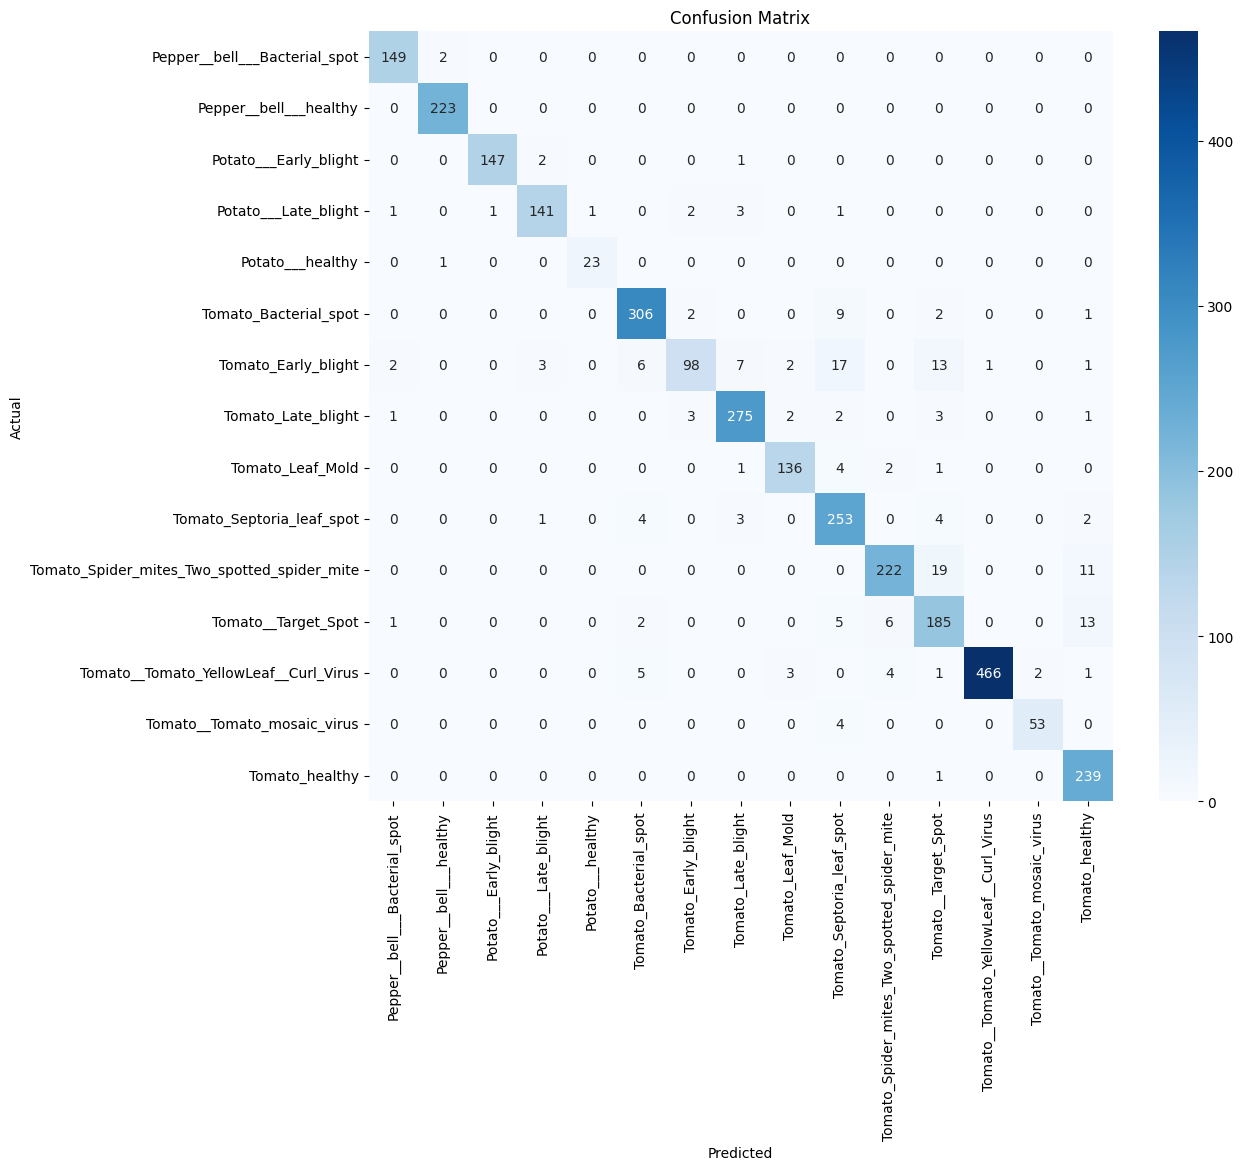

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
